In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

In [14]:
load_dotenv()
llm = init_chat_model(model="gemini-3.5-flash-lite", model_provider="google_genai")

In [15]:
class BATSMANstate(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int
    strike_rate : float
    runs_in_boundary_prc : float
    balls_per_boundary : float
    summary : str

In [16]:
def strike_rate_calculator(state : BATSMANstate):
    prompt = f"This is the runs: {state['balls']}, balls: {state['balls']}, fours: {state['fours']} & sixes: {state['sixes']}. Calculate the strike rate and return only the float value (strike_rate) in response."
    state['strike_rate'] = llm.invoke([HumanMessage(content=prompt)]).content
    return state

def runs_in_boundary_prc_calculator(state : BATSMANstate):
    prompt = f"This is the runs: {state['balls']}, balls: {state['balls']}, fours: {state['fours']} & sixes: {state['sixes']}. Calculate the runs_in_boundary_prc and return only the float value (runs_in_boundary_prc) in response."
    state['runs_in_boundary_prc'] = llm.invoke([HumanMessage(content=prompt)]).content
    return state

def balls_per_boundary_calculator(state : BATSMANstate):
    prompt = f"This is the runs: {state['balls']}, balls: {state['balls']}, fours: {state['fours']} & sixes: {state['sixes']}. Calculate the balls_per_boundary and return only the float value (balls_per_boundary) in response."
    state['balls_per_boundary'] = llm.invoke([HumanMessage(content=prompt)]).content
    return state

def summary_generator(state: BATSMANstate):
    prompt = f"""
    Analyze the following batsman's performance and write a concise 2-3 sentence summary highlighting their efficiency, boundaries, and scoring rate:

    - Runs: {state['runs']}
    - Balls: {state['balls']}
    - Fours: {state['fours']}
    - Sixes: {state['sixes']}
    - Strike Rate: {state['strike_rate']}
    - Balls per Boundary: {state['balls_per_boundary']}
    """
    state['summary'] = llm.invoke([HumanMessage(content=prompt)]).content
    return state

In [17]:
graph = StateGraph(BATSMANstate)

graph.add_node('strike_rate_calculator', strike_rate_calculator)
graph.add_node('runs_in_boundary_prc_calculator', runs_in_boundary_prc_calculator)
graph.add_node('balls_per_boundary_calculator', balls_per_boundary_calculator)
graph.add_node('summary_generator', summary_generator)

graph.add_edge(START, 'strike_rate_calculator')
graph.add_edge(START, 'runs_in_boundary_prc_calculator')
graph.add_edge(START, 'balls_per_boundary_calculator')
graph.add_edge('strike_rate_calculator', 'summary_generator')
graph.add_edge('runs_in_boundary_prc_calculator', 'summary_generator')
graph.add_edge('balls_per_boundary_calculator', 'summary_generator')
graph.add_edge('summary_generator', END)

workflow = graph.compile()

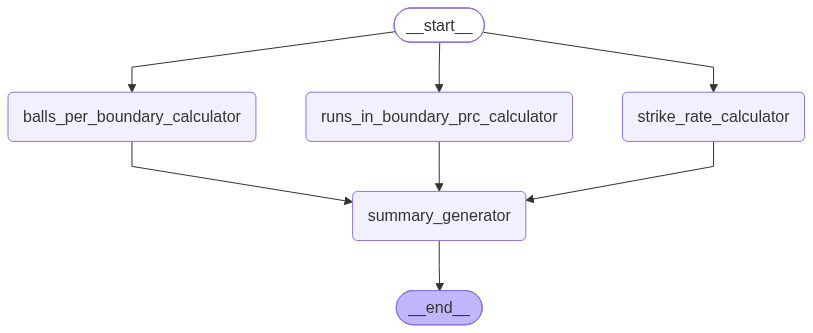

In [18]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [19]:
initial_state = {
    "runs": 82,
    "balls": 53,
    "fours": 6,
    "sixes": 4,
    "strike_rate": 0.0,
    "runs_in_boundary_prc": 0.0,
    "balls_per_boundary": 0.0,
    "summary": "",
}
final_state = workflow.invoke(initial_state)
print(final_state)

InvalidUpdateError: At key 'runs': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [ ]:
print(final_state["summary"][0]['text'])